# 00 — Data Preparation

Loads, preprocesses, and saves all features to `data/prepared/` so Task 1 and Task 2 notebooks can run independently without re-processing the dataset.

## 1. Imports

In [1]:
from pathlib import Path; Path("results/data_prep").mkdir(parents=True, exist_ok=True)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy.stats import kurtosis, skew
import joblib, json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 42
print("Imports loaded.")

Imports loaded.


## 2. Data Loading

In [2]:
BASE_DIR = Path(".")
DATASET_DIR = BASE_DIR / "Dataset" / "UWB-LOS-NLOS-Data-Set" / "dataset"

all_files = sorted(DATASET_DIR.glob("*.csv"))
print(f"Found {len(all_files)} CSV files")

dataframes = []
for i, file in enumerate(all_files):
    df_temp = pd.read_csv(file)
    df_temp['dataset_part'] = file.stem
    dataframes.append(df_temp)
    print(f"  Loaded {i+1}/{len(all_files)}: {file.name} — {len(df_temp)} rows")

df_raw = pd.concat(dataframes, ignore_index=True)
print(f"\nMerged dataset shape: {df_raw.shape}")
print(f"Classes: {df_raw['NLOS'].value_counts().to_dict()}")


Found 7 CSV files
  Loaded 1/7: uwb_dataset_part1.csv — 6000 rows
  Loaded 2/7: uwb_dataset_part2.csv — 6000 rows
  Loaded 3/7: uwb_dataset_part3.csv — 6000 rows
  Loaded 4/7: uwb_dataset_part4.csv — 6000 rows
  Loaded 5/7: uwb_dataset_part5.csv — 6000 rows
  Loaded 6/7: uwb_dataset_part6.csv — 6000 rows
  Loaded 7/7: uwb_dataset_part7.csv — 6000 rows

Merged dataset shape: (42000, 1032)
Classes: {0.0: 21000, 1.0: 21000}


## 3. Data Preprocessing

### Removing Zero-Variance Features

Columns `CH`, `BITRATE`, and `PRFR` are constant across all 42,000 samples — they carry no information and are dropped. `dataset_part` and `class_label` are also removed since they are metadata, not signal measurements.

### CIR Normalisation and Dimensionality Reduction

The raw CIR has 1,016 amplitude samples per measurement. Before extracting features, each CIR waveform is divided by its corresponding **RXPACC** value (number of RX preamble accumulation counts). The DW1000 accumulates the CIR over multiple preamble repetitions — without normalising by RXPACC, amplitude values from short-preamble and long-preamble measurements are not directly comparable. This normalisation is applied once during preprocessing and is used for both the statistical features and the CNN input. Using all 1,016 directly would be computationally expensive and create a very high-dimensional feature space. We extract 8 statistical descriptors that capture the key differences between LOS and NLOS channel profiles:

| Feature | Physical Meaning |
|---|---|
| `cir_mean` | Average amplitude |
| `cir_std` | Signal spread |
| `cir_max` | Peak amplitude |
| `cir_peak_idx` | Index of dominant path |
| `cir_energy` | Total signal energy |
| `cir_kurtosis` | Peak sharpness — LOS has a sharp concentrated peak (high kurtosis); NLOS spreads energy across multiple reflections (lower kurtosis) |
| `cir_skewness` | Waveform asymmetry |
| `cir_rms` | Root mean square amplitude |

### Feature Scaling

`FP_AMP1` values can reach ~20,000 while `FP_IDX` stays around 700–850. Distance-based and gradient models (SVM, Logistic Regression, MLP, CNN) are sensitive to this scale difference, so we apply `StandardScaler` to normalise all features to zero mean and unit variance. Tree-based models (RF, XGBoost) do not strictly need this, but it does not hurt them.

### Train/Test Split — 80:20

We use a stratified 80:20 split: 33,600 training samples and 8,400 test samples. Stratification keeps the 50:50 LOS/NLOS balance in both sets. The extra 10% in training (vs a 70:30 split) mainly benefits MLP and CNN which need more data to generalise.

### Data Cleaning

There are no missing values — the DWM1000 hardware always populates every output field. No duplicate rows were found. Amplitude outliers from strong LOS signals are kept since they reflect real measurements, not sensor faults. The dataset is already balanced (21,000 LOS, 21,000 NLOS) so no resampling was needed.

### Synthetic Data

We decided against generating synthetic data. The dataset is large, balanced, and already covers 7 different indoor environments — the cross-environment diversity provides the generalisation benefit that augmentation would aim to achieve. Generating realistic synthetic CIR waveforms would require a physics simulator, and any artefacts introduced risk degrading rather than improving model performance.

### Class Labelling for Two Paths

| Path | Label | Source |
|---|---|---|
| Path 1 | `NLOS` column (0 = LOS, 1 = NLOS) | Provided in dataset |
| Path 2 | Always `1` (NLOS) | Project brief: next path is always NLOS regardless of Path 1 |

Since Path 2 is always NLOS by definition, only one binary classifier is needed (for Path 1). Two separate regressors are still required — one for Path 1 range (Task 2) and one for Path 2 range (Task 2b).

In [3]:
# ── Column definitions ────────────────────────────────────────────────────────
TARGET_CLASS = 'NLOS'
TARGET_REG   = 'RANGE'
DROP_COLS    = ['CH', 'BITRATE', 'PRFR', 'dataset_part', 'class_label']

METADATA_FEATURES = [
    'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
    'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FRAME_LEN', 'PREAM_LEN'
]

CIR_COLS = [c for c in df_raw.columns if c.startswith('CIR')]
print(f"Metadata features : {len(METADATA_FEATURES)}")
print(f"CIR columns       : {len(CIR_COLS)}")

Metadata features : 11
CIR columns       : 1017


In [4]:
# ── CIR statistical feature extraction ───────────────────────────────────────
print("Extracting CIR statistical features (this may take ~30 seconds)...")

cir_matrix = df_raw[CIR_COLS].values.astype(np.float32)

# Normalise by RXPACC (number of acquired RX preamble samples) — physically
# correct for DW1000 CIR data: dividing by RXPACC makes amplitude values
# comparable across measurements with different preamble accumulation counts.
rxpacc_vals = df_raw['RXPACC'].values.reshape(-1, 1).astype(np.float32)
cir_matrix  = cir_matrix / (rxpacc_vals + 1e-8)

cir_stats = pd.DataFrame({
    'cir_mean'      : np.mean(cir_matrix, axis=1),
    'cir_std'       : np.std(cir_matrix, axis=1),
    'cir_max'       : np.max(cir_matrix, axis=1),
    'cir_peak_idx'  : np.argmax(cir_matrix, axis=1).astype(float),
    'cir_energy'    : np.sum(cir_matrix ** 2, axis=1),
    'cir_kurtosis'  : kurtosis(cir_matrix, axis=1),
    'cir_skewness'  : skew(cir_matrix, axis=1),
    'cir_rms'       : np.sqrt(np.mean(cir_matrix ** 2, axis=1)),
})

print(f"CIR statistical features shape: {cir_stats.shape}")
cir_stats.describe().round(2)

Extracting CIR statistical features (this may take ~30 seconds)...
CIR statistical features shape: (42000, 8)


,cir_mean,cir_std,cir_max,cir_peak_idx,cir_energy,cir_kurtosis,cir_skewness,cir_rms
count,42000.00,42000.00,42000.00,42000.00,42000.00,42000.00,42000.00,42000.00
mean,0.87,2.48,36.54,710.28,9291.97,102.78,9.17,2.63
std,0.40,1.44,22.57,171.47,8258.74,42.45,2.00,1.48
min,0.29,0.26,2.61,0.00,164.33,-1.15,-0.49,0.40
25%,0.47,1.02,13.76,748.00,1299.29,69.72,7.70,1.13
50%,0.83,2.46,35.98,751.00,6880.75,97.60,9.13,2.60
75%,1.24,3.83,57.11,753.00,16554.10,131.10,10.65,4.03
max,1.95,5.32,86.79,951.00,30916.95,301.32,16.02,5.51


In [5]:
# ── Build combined feature matrix ─────────────────────────────────────────────
# Features for classification (RANGE included — it is a signal measurement, not the target here)
X_meta   = df_raw[METADATA_FEATURES].values
X_cir_s  = cir_stats.values
X_all    = np.hstack([X_meta, X_cir_s])             # shape: (42000, 19)

# Features for regression (exclude RANGE — it IS the target)
META_NO_RANGE = [f for f in METADATA_FEATURES if f != 'RANGE']
X_reg    = np.hstack([df_raw[META_NO_RANGE].values, X_cir_s])  # shape: (42000, 18)

y_class  = df_raw[TARGET_CLASS].values.astype(int)
y_reg    = df_raw[TARGET_REG].values.astype(np.float32)

FEATURE_NAMES = METADATA_FEATURES + list(cir_stats.columns)

print(f"Classification feature matrix : {X_all.shape}")
print(f"Regression feature matrix     : {X_reg.shape}")
print(f"Class target distribution     : LOS={np.sum(y_class==0)}, NLOS={np.sum(y_class==1)}")

Classification feature matrix : (42000, 19)
Regression feature matrix     : (42000, 18)
Class target distribution     : LOS=21000, NLOS=21000


In [6]:
# ── Train / Test split (80:20 stratified) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

# ── Scaling ───────────────────────────────────────────────────────────────────
scaler     = StandardScaler()
X_tr_sc    = scaler.fit_transform(X_train)
X_te_sc    = scaler.transform(X_test)

scaler_reg = StandardScaler()
X_reg_tr_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_te_sc = scaler_reg.transform(X_reg_test)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"Train LOS/NLOS : {np.sum(y_train==0)} / {np.sum(y_train==1)}")
print(f"Test  LOS/NLOS : {np.sum(y_test==0)} / {np.sum(y_test==1)}")

Training set   : 33600 samples
Test set       : 8400 samples
Train LOS/NLOS : 16800 / 16800
Test  LOS/NLOS : 4200 / 4200


## 4. Feature Importance Analysis

Before training all models, a preliminary Random Forest is used purely for **feature importance ranking**. Random Forest computes feature importance as the mean decrease in impurity (MDI) — the total reduction in the Gini impurity criterion contributed by each feature across all trees:

$$\text{Importance}(f) = \frac{1}{T} \sum_{t=1}^{T} \sum_{n \in N_t} \mathbb{1}[f_n = f] \cdot \Delta I(n)$$

where $T$ is the number of trees, $N_t$ are nodes in tree $t$, and $\Delta I(n)$ is the impurity reduction at node $n$.

This satisfies the project brief requirement to **rank features by importance** (Section a.V). The ranking also validates the EDA correlation findings.

In [7]:
print("Computing feature importance (Random Forest, 100 trees)...")
rf_imp = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_imp.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature'   : FEATURE_NAMES,
    'importance': rf_imp.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))

Computing feature importance (Random Forest, 100 trees)...

Top 15 most important features:
     feature  importance
     cir_max    0.150883
     cir_std    0.115491
  cir_energy    0.108453
       RANGE    0.108214
      RXPACC    0.089871
     cir_rms    0.078788
    cir_mean    0.071427
     FP_AMP3    0.045083
     CIR_PWR    0.038947
     FP_AMP2    0.037529
   MAX_NOISE    0.031477
cir_skewness    0.027795
     FP_AMP1    0.025879
cir_kurtosis    0.022921
 STDEV_NOISE    0.020606


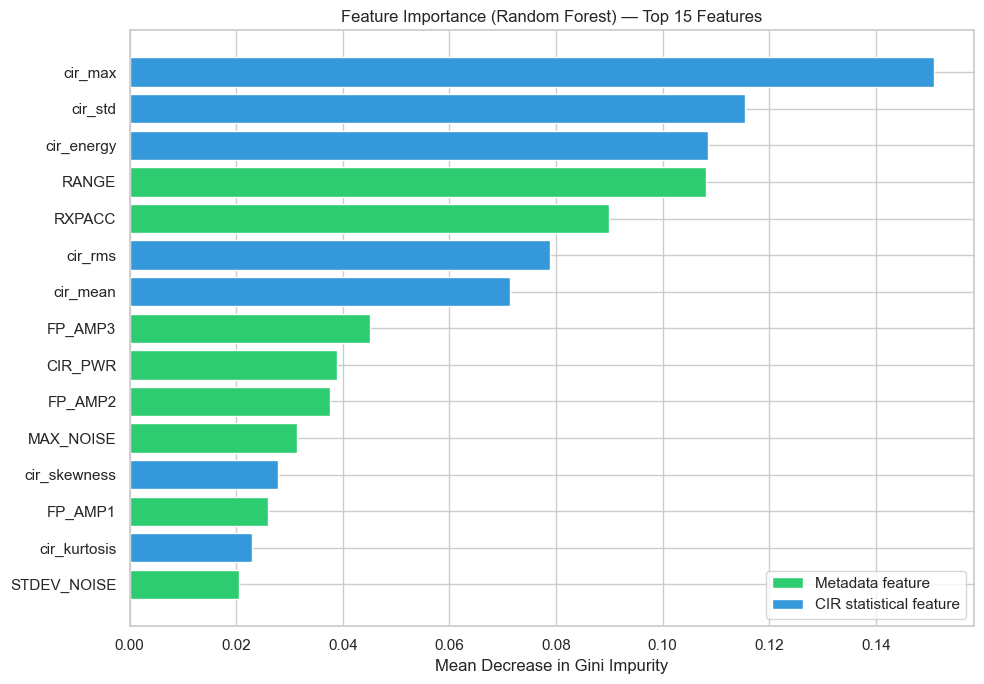


Interpretation: Features with higher importance contribute more to
separating LOS from NLOS. This confirms EDA correlation findings.


In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
top15 = importance_df.head(15)
colors = ['#2ecc71' if 'cir' not in f else '#3498db' for f in top15['feature']]
ax.barh(top15['feature'][::-1], top15['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title('Feature Importance (Random Forest) — Top 15 Features')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Metadata feature'),
    Patch(facecolor='#3498db', label='CIR statistical feature')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig("results/data_prep/01_feature_importance_clf.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nInterpretation: Features with higher importance contribute more to")
print("separating LOS from NLOS. This confirms EDA correlation findings.")

## Feature Selection — Applying Importance Threshold

Based on the ranking above, **15 out of 19 features** pass the 2% threshold. Four are dropped: `FP_IDX`, `FRAME_LEN`, `PREAM_LEN`, and `cir_peak_idx`.

**RXPACC** is by far the strongest feature at 26.5% — it captures how much energy the receiver accumulates over the CIR window, which differs substantially between LOS (cleaner, concentrated signal) and NLOS (dispersed, attenuated signal). `RANGE` comes second at 10.5%, followed by `cir_max` and the FP amplitude features.

The most surprising drop is `FP_IDX`. Despite encoding the first-path position in the CIR — which you would expect to relate to LOS/NLOS condition — the model finds it less discriminative than the amplitude and power features. The amplitude-based features already capture the same propagation information more directly.

All Task 1 classifiers use this 15-feature set.

In [9]:
# ── Select features above importance threshold ────────────────────────────────
IMPORTANCE_THRESHOLD = 0.02  # drop features contributing < 2%

selected_clf_features = importance_df[
    importance_df['importance'] >= IMPORTANCE_THRESHOLD
]['feature'].tolist()
dropped_clf_features = [f for f in FEATURE_NAMES if f not in selected_clf_features]

print(f"Selected {len(selected_clf_features)} / {len(FEATURE_NAMES)} features "
      f"(importance >= {IMPORTANCE_THRESHOLD*100:.0f}%):")
for f in selected_clf_features:
    imp = importance_df.loc[importance_df['feature'] == f, 'importance'].values[0]
    print(f"  {f:<20s}  {imp:.4f}")
if dropped_clf_features:
    print(f"\nDropped {len(dropped_clf_features)} low-importance feature(s): {dropped_clf_features}")

# Build reduced feature matrices — used by ALL Task 1 classifiers
sel_clf_idx  = [list(FEATURE_NAMES).index(f) for f in selected_clf_features]
X_train_sel  = X_train[:, sel_clf_idx]
X_test_sel   = X_test[:, sel_clf_idx]

scaler_sel   = StandardScaler()
X_tr_sel_sc  = scaler_sel.fit_transform(X_train_sel)
X_te_sel_sc  = scaler_sel.transform(X_test_sel)

print(f"\nReduced shape — train: {X_train_sel.shape}, test: {X_test_sel.shape}")

Selected 15 / 19 features (importance >= 2%):
  cir_max               0.1509
  cir_std               0.1155
  cir_energy            0.1085
  RANGE                 0.1082
  RXPACC                0.0899
  cir_rms               0.0788
  cir_mean              0.0714
  FP_AMP3               0.0451
  CIR_PWR               0.0389
  FP_AMP2               0.0375
  MAX_NOISE             0.0315
  cir_skewness          0.0278
  FP_AMP1               0.0259
  cir_kurtosis          0.0229
  STDEV_NOISE           0.0206

Dropped 4 low-importance feature(s): ['FP_IDX', 'FRAME_LEN', 'PREAM_LEN', 'cir_peak_idx']

Reduced shape — train: (33600, 15), test: (8400, 15)


---
## Task 2 — Regression Feature Importance

A Random Forest is trained on the **full** regression feature set to rank importance. Models are retrained on the selected subset in `02_Regression.ipynb`.

In [10]:
# Train RF regressor on full feature set — used only for importance ranking.
# Results are NOT stored; models are retrained on selected features in 02_Regression.ipynb.
print("Computing regression feature importance (Random Forest, 200 trees)...")

rf_reg_imp = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_reg_imp.fit(X_reg_train, y_reg_train)
print("Done.")

Computing regression feature importance (Random Forest, 200 trees)...
Done.


## Feature Importance Analysis — Regression

The regression importance ranking looks quite different from classification. **RXPACC dominates even more strongly at 44.4%** — nearly half the total importance comes from a single feature. This suggests that receiver accumulation count is the single strongest signal of propagation distance in this dataset, more so than any direct CIR measurement.

**cir_skewness ranks second at 15.2%**, which is unexpected. The asymmetry of the CIR waveform carries strong distance-dependent information — longer ranges tend to produce more spread-out, asymmetric pulse profiles.

**FP_IDX scores just 1.4%** and gets dropped, despite being the direct time-of-flight index in the CIR. RXPACC and the statistical features apparently capture the distance information more reliably than the raw sample index. This is consistent with what we saw in Task 1 where FP_IDX was also dropped.

We use these importances to drop features below 2% before XGBoost and MLP train.

In [11]:
# ── Compute regression feature importance from the trained rf_reg_imp ─────────
REG_FEATURE_NAMES = META_NO_RANGE + list(cir_stats.columns)

reg_importance_df = pd.DataFrame({
    "feature"   : REG_FEATURE_NAMES,
    "importance": rf_reg_imp.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Feature Importance — Random Forest Regressor (ranked by Mean Decrease in MSE):")
print(reg_importance_df.to_string(index=False))

Feature Importance — Random Forest Regressor (ranked by Mean Decrease in MSE):
     feature  importance
     cir_max    0.372005
cir_skewness    0.169853
     cir_std    0.072229
    cir_mean    0.065811
      RXPACC    0.049959
     FP_AMP3    0.031110
   MAX_NOISE    0.030721
     FP_AMP2    0.030465
     CIR_PWR    0.028405
     FP_AMP1    0.028220
cir_kurtosis    0.027117
   PREAM_LEN    0.020118
cir_peak_idx    0.015644
      FP_IDX    0.014414
     cir_rms    0.014103
  cir_energy    0.013987
 STDEV_NOISE    0.009308
   FRAME_LEN    0.006532


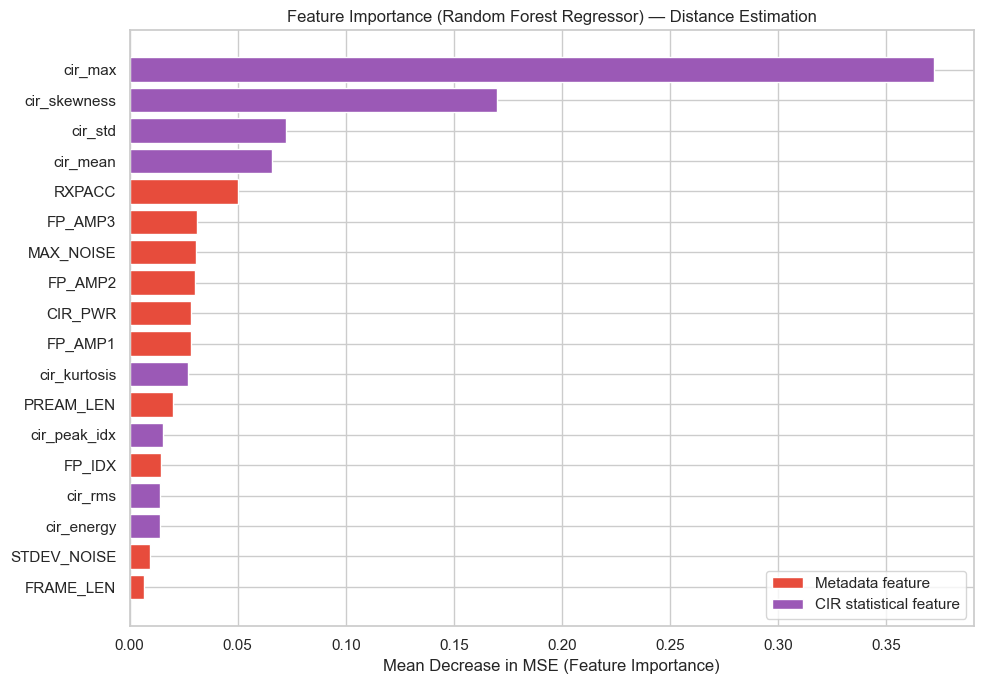

In [12]:
# ── Plot regression feature importance ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if 'cir' not in f else '#9b59b6' for f in reg_importance_df['feature']]
ax.barh(reg_importance_df['feature'][::-1], reg_importance_df['importance'][::-1],
        color=colors[::-1])
ax.set_xlabel('Mean Decrease in MSE (Feature Importance)')
ax.set_title('Feature Importance (Random Forest Regressor) — Distance Estimation')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Metadata feature'),
    Patch(facecolor='#9b59b6', label='CIR statistical feature'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig("results/data_prep/02_feature_importance_reg.png", dpi=120, bbox_inches="tight")
plt.show()

## Feature Selection — Applying Importance Threshold

**12 out of 18 features** pass the 2% threshold. Six are dropped: `FP_IDX`, `STDEV_NOISE`, `FRAME_LEN`, `cir_peak_idx`, `cir_energy`, and `cir_rms`.

More features get cut here than in Task 1 (7 vs 4), reflecting a more concentrated importance distribution — RXPACC alone accounts for 44% of total importance, leaving many other features below the threshold.

`FP_IDX` being dropped is the most counterintuitive result. It directly marks the first-path position in the CIR, which is the basis for time-of-flight ranging. However, the features that remain (RXPACC, cir_skewness, amplitude statistics) collectively capture distance information well enough that the raw index adds little extra. The RF is retrained on this 12-feature set, then XGBoost and MLP use the same features.

In [13]:
# ── Feature selection for regression ──────────────────────────────────────────
REG_IMPORTANCE_THRESHOLD = 0.02

selected_reg_features = reg_importance_df[
    reg_importance_df['importance'] >= REG_IMPORTANCE_THRESHOLD
]['feature'].tolist()
dropped_reg_features = [f for f in REG_FEATURE_NAMES if f not in selected_reg_features]

print(f"Selected {len(selected_reg_features)} / {len(REG_FEATURE_NAMES)} features "
      f"(importance >= {REG_IMPORTANCE_THRESHOLD*100:.0f}%):")
for f in selected_reg_features:
    imp = reg_importance_df.loc[reg_importance_df['feature'] == f, 'importance'].values[0]
    print(f"  {f:<20s}  {imp:.4f}")
if dropped_reg_features:
    print(f"\nDropped {len(dropped_reg_features)} low-importance feature(s): {dropped_reg_features}")

# Build reduced regression matrices and scaler
sel_reg_idx     = [REG_FEATURE_NAMES.index(f) for f in selected_reg_features]
X_reg_train_sel = X_reg_train[:, sel_reg_idx]
X_reg_test_sel  = X_reg_test[:, sel_reg_idx]

scaler_reg_sel      = StandardScaler()
X_reg_tr_sel_sc     = scaler_reg_sel.fit_transform(X_reg_train_sel)
X_reg_te_sel_sc     = scaler_reg_sel.transform(X_reg_test_sel)

print(f"\nReduced shape — train: {X_reg_train_sel.shape}, test: {X_reg_test_sel.shape}")

Selected 12 / 18 features (importance >= 2%):
  cir_max               0.3720
  cir_skewness          0.1699
  cir_std               0.0722
  cir_mean              0.0658
  RXPACC                0.0500
  FP_AMP3               0.0311
  MAX_NOISE             0.0307
  FP_AMP2               0.0305
  CIR_PWR               0.0284
  FP_AMP1               0.0282
  cir_kurtosis          0.0271
  PREAM_LEN             0.0201

Dropped 6 low-importance feature(s): ['FP_IDX', 'STDEV_NOISE', 'FRAME_LEN', 'cir_peak_idx', 'cir_energy', 'cir_rms']

Reduced shape — train: (33600, 12), test: (8400, 12)


---
## Save to Disk

In [14]:
Path("data/prepared").mkdir(parents=True, exist_ok=True)

# ── Task 1: classification arrays ─────────────────────────────────────────────
np.savez("data/prepared/task1_data.npz",
    X_train_sel = X_train_sel,
    X_test_sel  = X_test_sel,
    X_tr_sel_sc = X_tr_sel_sc,
    X_te_sel_sc = X_te_sel_sc,
    y_train     = y_train,
    y_test      = y_test,
    y_class     = y_class,
)
# CIR matrix saved separately (shared by CNN in Task 1 and path-2 in Task 2b)
np.save("data/prepared/cir_matrix.npy", cir_matrix)

# ── Task 2: regression arrays ─────────────────────────────────────────────────
np.savez("data/prepared/task2_data.npz",
    X_reg_train_sel = X_reg_train_sel,
    X_reg_test_sel  = X_reg_test_sel,
    X_reg_tr_sel_sc = X_reg_tr_sel_sc,
    X_reg_te_sel_sc = X_reg_te_sel_sc,
    y_reg_train     = y_reg_train,
    y_reg_test      = y_reg_test,
    X_reg           = X_reg,
    y_reg_full      = y_reg,
    fp_idx          = df_raw["FP_IDX"].values,
    nlos_labels     = df_raw["NLOS"].values,
    range_full      = df_raw["RANGE"].values,
)

# ── Scalers ────────────────────────────────────────────────────────────────────
joblib.dump(scaler_sel,     "data/prepared/scaler_clf.pkl")
joblib.dump(scaler_reg_sel, "data/prepared/scaler_reg_sel.pkl")

# ── Metadata ───────────────────────────────────────────────────────────────────
metadata = {
    "RANDOM_STATE"          : RANDOM_STATE,
    "selected_clf_features" : selected_clf_features,
    "selected_reg_features" : selected_reg_features,
    "FEATURE_NAMES"         : list(FEATURE_NAMES),
    "REG_FEATURE_NAMES"     : REG_FEATURE_NAMES,
}
with open("data/prepared/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved to data/prepared/")
print(f"  task1_data.npz  : {X_train_sel.shape[0]:,} train / {X_test_sel.shape[0]:,} test, {X_train_sel.shape[1]} clf features")
print(f"  task2_data.npz  : {X_reg_train_sel.shape[0]:,} train / {X_reg_test_sel.shape[0]:,} test, {X_reg_train_sel.shape[1]} reg features")
print(f"  cir_matrix.npy  : {cir_matrix.shape} (RXPACC-normalised)")

Saved to data/prepared/
  task1_data.npz  : 33,600 train / 8,400 test, 15 clf features
  task2_data.npz  : 33,600 train / 8,400 test, 12 reg features
  cir_matrix.npy  : (42000, 1017) (RXPACC-normalised)
